In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("airquality.csv")

In [2]:
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

  country              state        city  \
0   India     Andhra_Pradesh  Vijayawada   
1   India  Arunachal_Pradesh  Naharlagun   
2   India  Arunachal_Pradesh  Naharlagun   
3   India              Assam    Byrnihat   
4   India              Assam    Byrnihat   

                                    station          last_update   latitude  \
0           Rajiv Nagar, Vijayawada - APPCB  11-04-2026 22:00:00  16.554731   
1           Naharlagun, Naharlagun - APSPCB  11-04-2026 22:00:00  27.103358   
2           Naharlagun, Naharlagun - APSPCB  11-04-2026 22:00:00  27.103358   
3  Central Academy for SFS, Byrnihat - PCBA  11-04-2026 22:00:00  26.071318   
4  Central Academy for SFS, Byrnihat - PCBA  11-04-2026 22:00:00  26.071318   

   longitude pollutant_id  pollutant_min  pollutant_max  pollutant_avg  
0  80.649110           CO           16.0           38.0           29.0  
1  93.679645          SO2            9.0           10.0           10.0  
2  93.679645           CO            7.0 

In [3]:
df = df.fillna(df.mean(numeric_only=True))

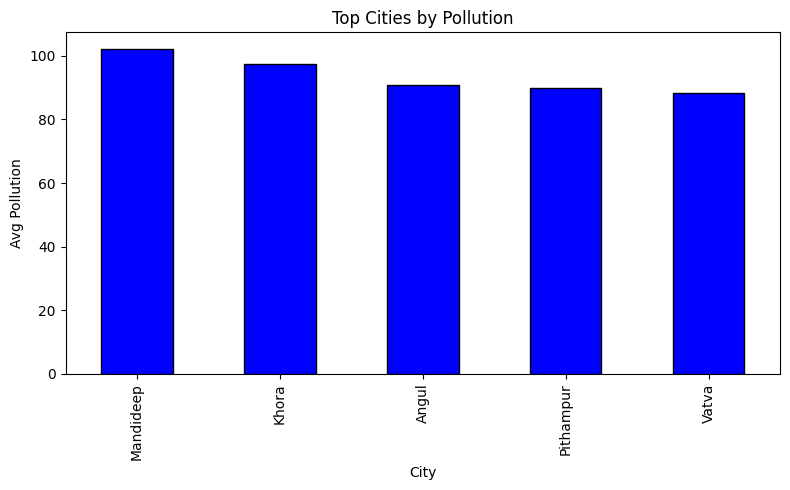

In [24]:
plt.figure(figsize=(8,5))
df.groupby('city')['pollutant_avg'].mean().sort_values(ascending=False).head(5).plot(kind='bar', color='blue', edgecolor='black')
plt.title("Top Cities by Pollution")
plt.xlabel("City")
plt.ylabel("Avg Pollution")
plt.tight_layout()
plt.show()

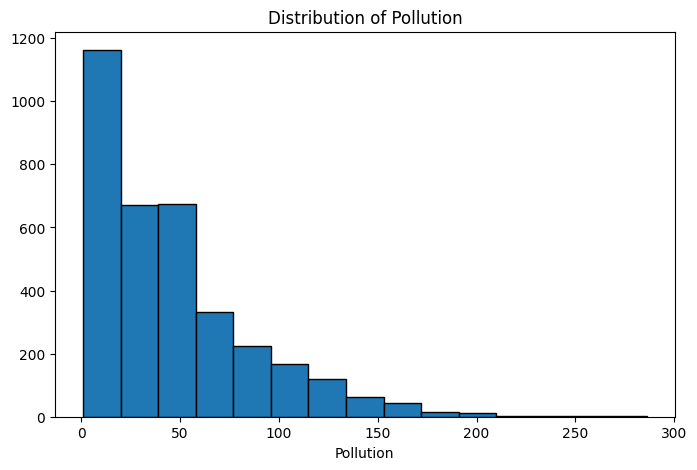

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df['pollutant_avg'], bins=15, edgecolor='black')
plt.title("Distribution of Pollution")
plt.xlabel("Pollution")
plt.show()

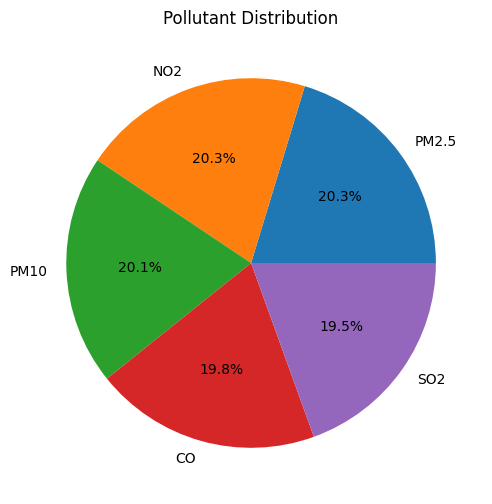

In [9]:
plt.figure(figsize=(6,6))
df['pollutant_id'].value_counts().head(5).plot(
    kind='pie', autopct='%1.1f%%'
)
plt.title("Pollutant Distribution")
plt.ylabel("")
plt.show()

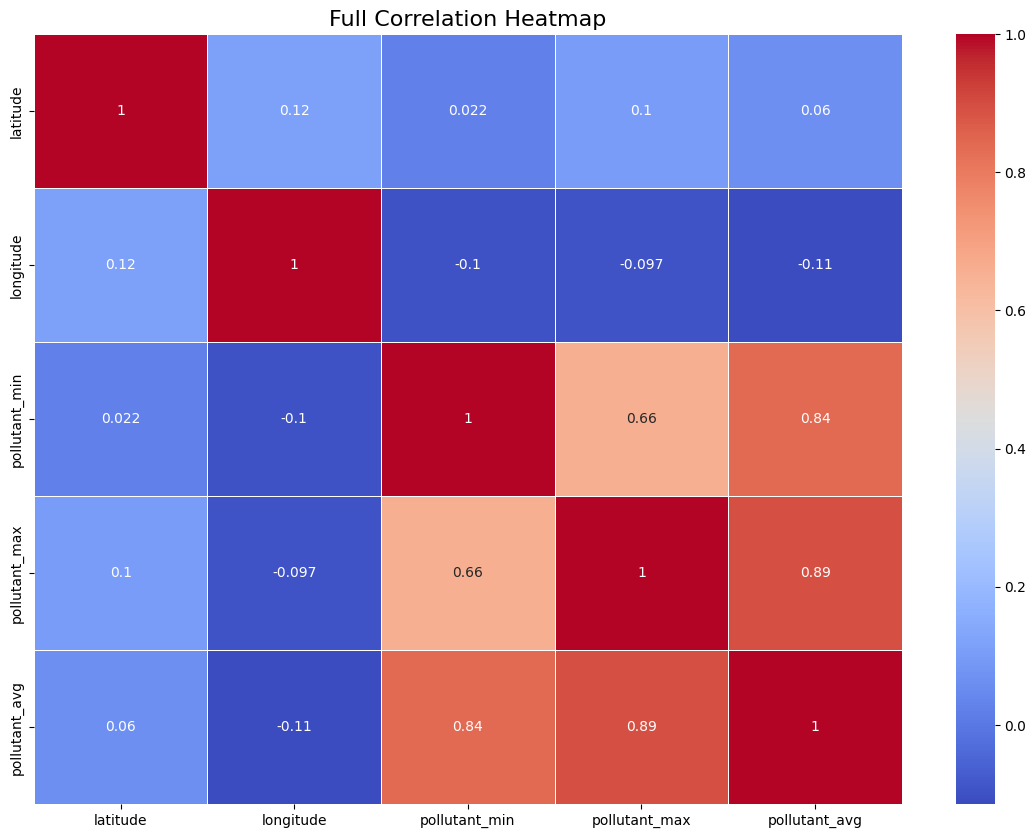

In [12]:
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(14,10))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Full Correlation Heatmap", fontsize=16)
plt.show()

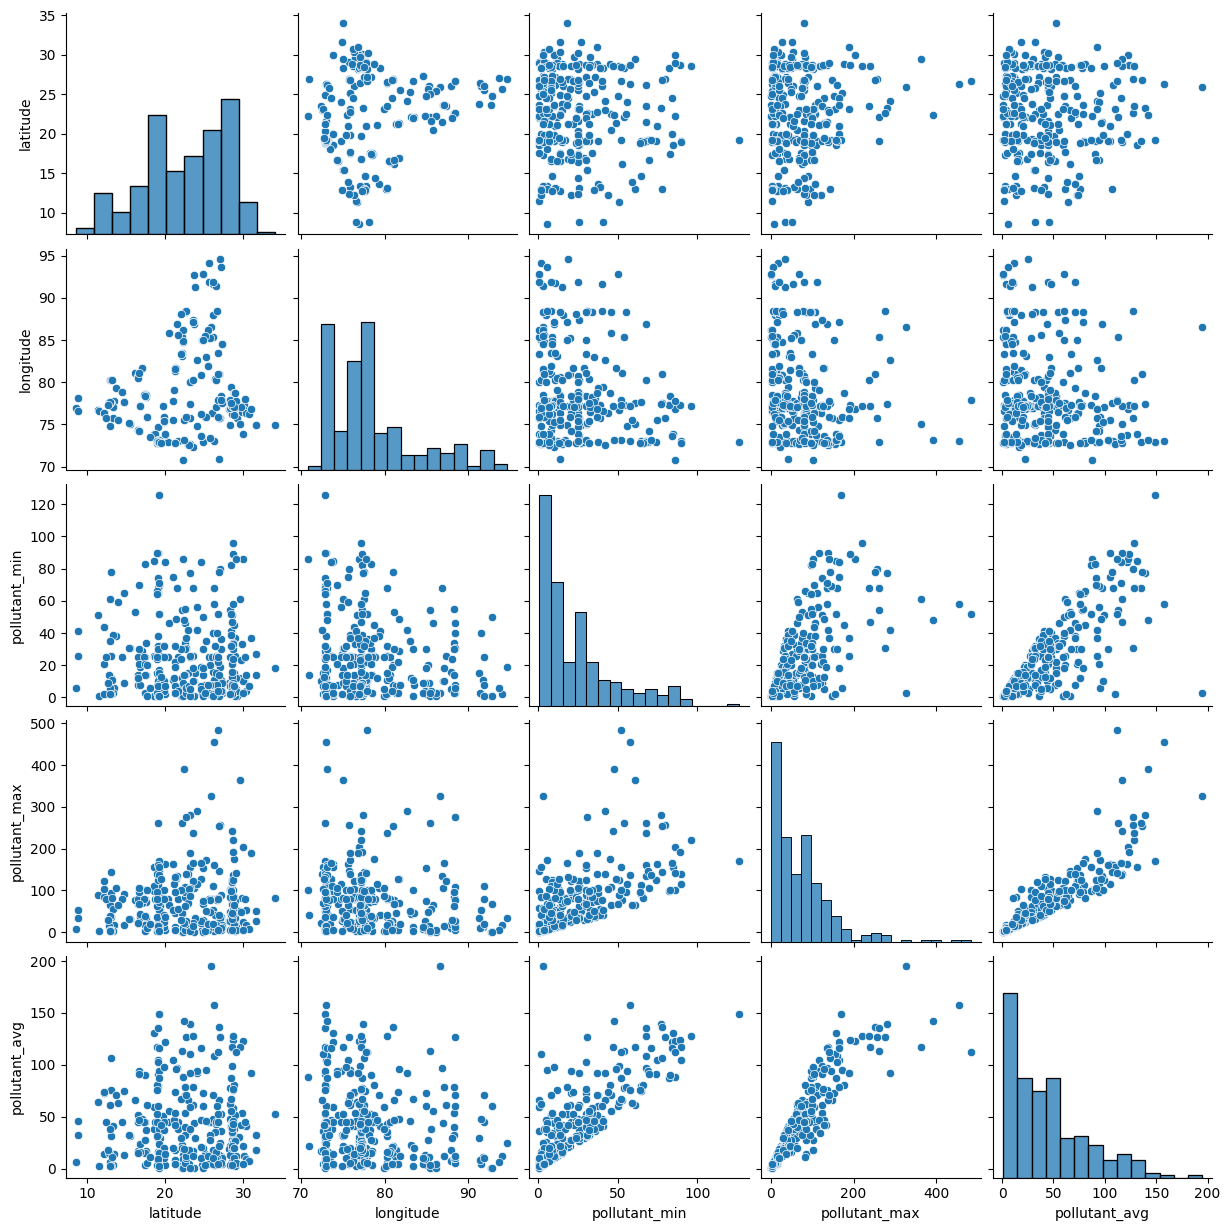

In [13]:
pair_df = df[['latitude','longitude','pollutant_min','pollutant_max','pollutant_avg']].sample(300)
sns.pairplot(pair_df)

In [14]:
from scipy.stats import ttest_ind
group1 = df[df['pollutant_id'] == 'PM2.5']['pollutant_avg']
group2 = df[df['pollutant_id'] == 'PM10']['pollutant_avg']
t_stat, p_val = ttest_ind(group1, group2, nan_policy='omit')
print("T-Statistic:", t_stat)
print("P-Value:", p_val)

T-Statistic: -10.061862512730059
P-Value: 8.861061201813495e-23


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
X = df[['latitude', 'longitude', 'pollutant_min', 'pollutant_max']]
y = df['pollutant_avg']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Linear Regression R2: 0.9052315058060897


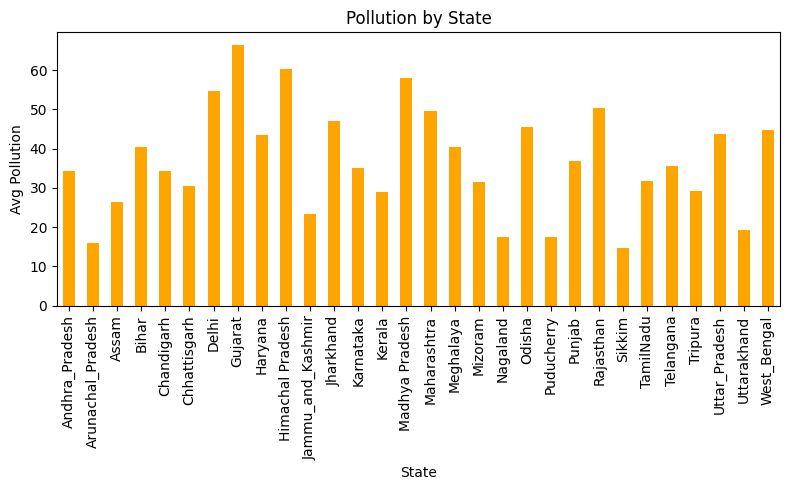

In [17]:
plt.figure(figsize=(8,5))
df.groupby('state')['pollutant_avg'].mean().plot(kind='bar', color='orange')
plt.title("Pollution by State")
plt.xlabel("State")
plt.ylabel("Avg Pollution")
plt.tight_layout()
plt.show()

In [18]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [19]:
y_pred = rf.predict(X_test)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 5.869866309930956
MSE: 122.61734511938073
R2 Score: 0.923514395546352


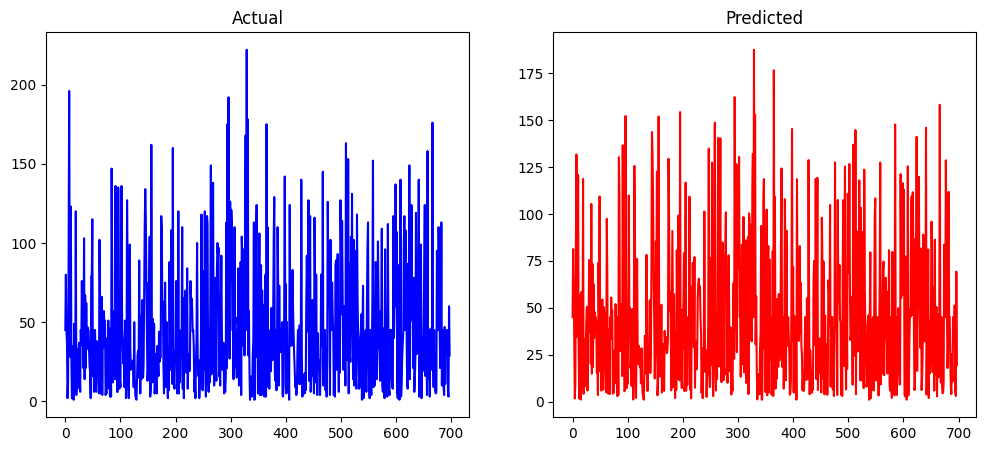

In [21]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(y_test.values, color='blue')
plt.title("Actual")
plt.subplot(1,2,2)
plt.plot(y_pred, color='red')
plt.title("Predicted")
plt.show()

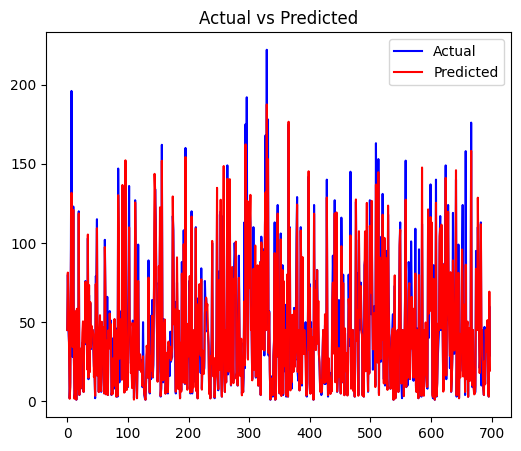

In [22]:
plt.figure(figsize=(6,5))
plt.plot(y_test.values, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='red')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

(array([1.162e+03, 6.700e+02, 4.700e+02, 3.330e+02, 2.230e+02, 1.670e+02,
        1.200e+02, 6.400e+01, 4.300e+01, 1.600e+01, 1.200e+01, 1.000e+00,
        3.000e+00, 1.000e+00, 1.000e+00]),
 array([  1.,  20.,  39.,  58.,  77.,  96., 115., 134., 153., 172., 191.,
        210., 229., 248., 267., 286.]),
 <BarContainer object of 15 artists>)

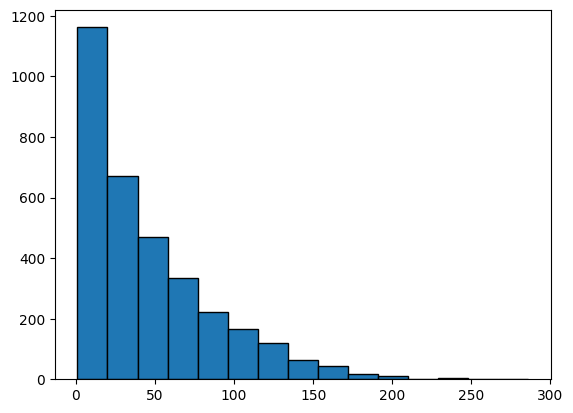

In [6]:
plt.hist(df['pollutant_avg'], bins=15, edgecolor='black')

In [7]:
df['pollutant_avg'].mean()

np.float64(45.0468654899574)